<a href="https://colab.research.google.com/github/visalakshijoga10/MasterThesisEmployeeAttritionIntention/blob/Employee_Attrition_Intention/employee_attrition_intention_for_thesis_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**A DATA-DRIVEN COMPARISON OF MACHINE LEARNING MODELS FOR PREDICTING EMPLOYEE ATTRITION INTENTION**

This notebook contains the full experiment for predicting employee attrition intention using four machine learning models: Logistic Regression, Decision Tree, Random Forest, and Support Vector Machine. SHAP analysis is applied to the best-performing model to explain the key factors influencing attrition intention.

1. Data Loading and Initial Inspection

The survey dataset is loaded from the CSV file. Column names are cleaned to remove extra spaces.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

2. Data Preprocessing

Missing values are checked, age groups are created for visualisation, and the target variable AttritionIntention is converted to integer format.

In [ ]:
data = pd.read_csv("Employee_Attrition_Intention Survey for thesis  Form Responses.csv")
data.columns = data.columns.str.strip()

In [ ]:
data["AgeGroup"] = pd.cut(
    data["Age"],
    bins=[18, 25, 35, 45, 70],
    labels=["18-25", "26-35", "36-45", "46-70"],
    include_lowest=True
)

In [ ]:
print(data.shape)
print(data.head())
print(data.info())

(378, 25)
   Age  Gender  MaritalStatus  Education  EducationField  Department  JobRole  \
0   45       0              1          4               2           5        5   
1   27       1              0          2               2           1        1   
2   22       1              0          2               1           3        3   
3   29       0              0          2               2           1        1   
4   32       0              0          4               2           1        2   

   JobLevel  DailyWorkTravel  DistanceFromHome  ...  JobSatisfaction  \
0         5                4                 3  ...                5   
1         3                1                 2  ...                3   
2         2                5                 3  ...                3   
3         2                2                 1  ...                4   
4         3                2                 1  ...                4   

   TotalWorkExperience  YearsAtCompany  YearsInCurrentRole  \
0       

In [ ]:
data = data.dropna().copy()
data["AttritionIntention"] = data["AttritionIntention"].astype(int)

In [ ]:
print(data.dtypes)

print(data.shape)
print(data["AttritionIntention"].value_counts())

Age                                     int64
Gender                                  int64
MaritalStatus                           int64
Education                               int64
EducationField                          int64
Department                              int64
JobRole                                 int64
JobLevel                                int64
DailyWorkTravel                         int64
DistanceFromHome                        int64
OverTime                                int64
WorkLifeBalance                         int64
EnvironmentSatisfaction                 int64
JobInvolvement                          int64
ColleagueRelationshipSatisfaction       int64
JobSatisfaction                         int64
TotalWorkExperience                     int64
YearsAtCompany                          int64
YearsInCurrentRole                      int64
YearsSinceLastPromotion                 int64
TrainingProgramsLastYear                int64
MonthlyIncome                     

**3. Exploratory Data Analysis (EDA)**

Visual exploration of the dataset to understand the distribution of responses and identify key patterns related to attrition intention.

3.1 Attrition Intention Distribution

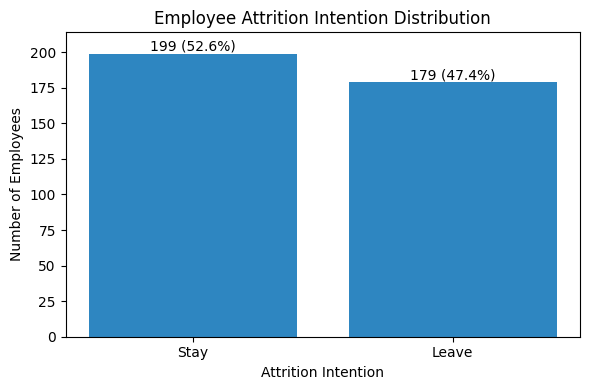

In [ ]:
counts = data["AttritionIntention"].value_counts().sort_index()

plt.figure(figsize=(6,4))

bars = plt.bar(counts.index, counts.values, color="#2E86C1")

plt.title("Employee Attrition Intention Distribution", fontsize=12)
plt.xlabel("Attrition Intention")
plt.ylabel("Number of Employees")

plt.xticks([0,1], ["Stay", "Leave"])

total = counts.sum()

for bar in bars:
    yval = bar.get_height()
    percent = (yval / total) * 100
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2,
             f"{int(yval)} ({percent:.1f}%)",
             ha="center", fontsize=10)

plt.ylim(0, max(counts.values) + 15)

plt.tight_layout()
plt.show()

3.2 Job Satisfaction vs Attrition Intention

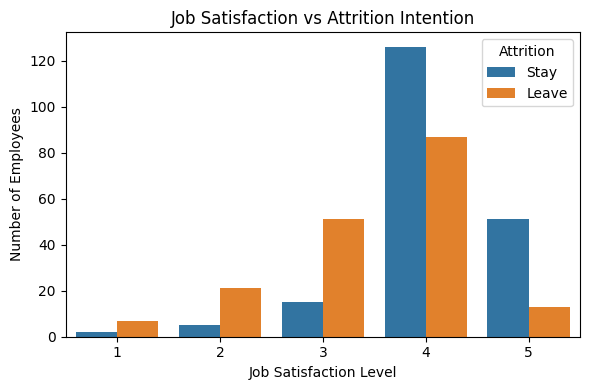

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x="JobSatisfaction", hue="AttritionIntention", data=data)

plt.title("Job Satisfaction vs Attrition Intention", fontsize=12)
plt.xlabel("Job Satisfaction Level")
plt.ylabel("Number of Employees")

plt.legend(title="Attrition", labels=["Stay", "Leave"])

plt.tight_layout()
plt.show()

3.3 Environment Satisfaction vs Attrition Intention

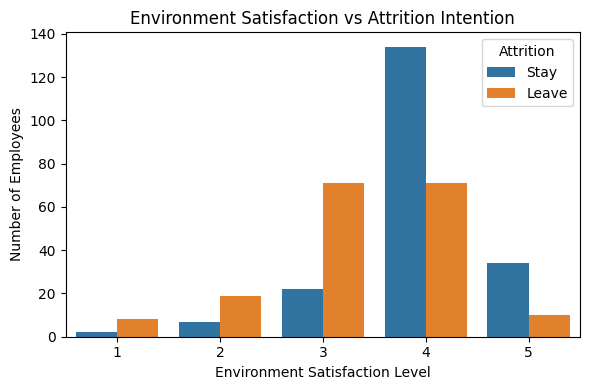

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="EnvironmentSatisfaction",
    hue="AttritionIntention",
    data=data
)

plt.title("Environment Satisfaction vs Attrition Intention", fontsize=12)
plt.xlabel("Environment Satisfaction Level")
plt.ylabel("Number of Employees")

plt.legend(title="Attrition", labels=["Stay", "Leave"])

plt.tight_layout()
plt.show()

3.4 Work-Life Balance vs Attrition Intention

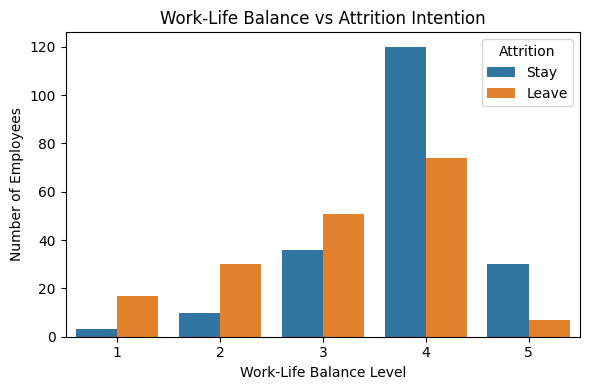

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="WorkLifeBalance",
    hue="AttritionIntention",
    data=data
)

plt.title("Work-Life Balance vs Attrition Intention", fontsize=12)
plt.xlabel("Work-Life Balance Level")
plt.ylabel("Number of Employees")

plt.legend(title="Attrition", labels=["Stay", "Leave"])

plt.tight_layout()
plt.show()

3.5 Overtime vs Attrition Intention

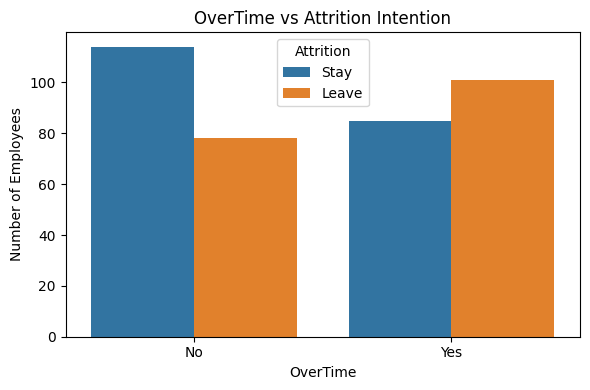

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="OverTime",
    hue="AttritionIntention",
    data=data
)

plt.title("OverTime vs Attrition Intention", fontsize=12)
plt.xlabel("OverTime")
plt.ylabel("Number of Employees")

plt.xticks([0,1], ["No", "Yes"])

plt.legend(title="Attrition", labels=["Stay", "Leave"])

plt.tight_layout()
plt.show()

3.6 Age Group vs Attrition Intention

In [ ]:
data["AgeGroup"] = pd.cut(
    data["Age"],
    bins=[18, 25, 35, 45, 70],
    labels=["18-25", "26-35", "36-45", "46-70"]
)

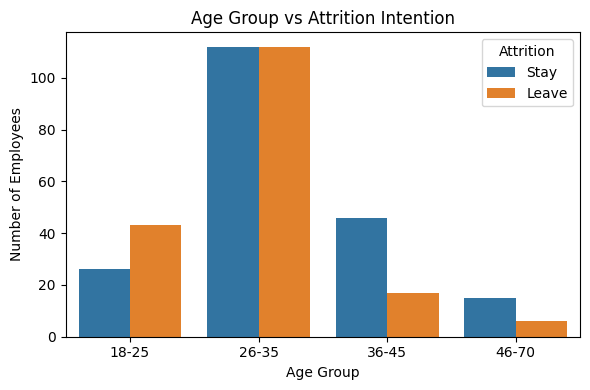

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="AgeGroup",
    hue="AttritionIntention",
    data=data
)

plt.title("Age Group vs Attrition Intention")
plt.xlabel("Age Group")
plt.ylabel("Number of Employees")
plt.legend(title="Attrition", labels=["Stay", "Leave"])

plt.tight_layout()
plt.show()

3.7 Job Level vs Attrition Intention



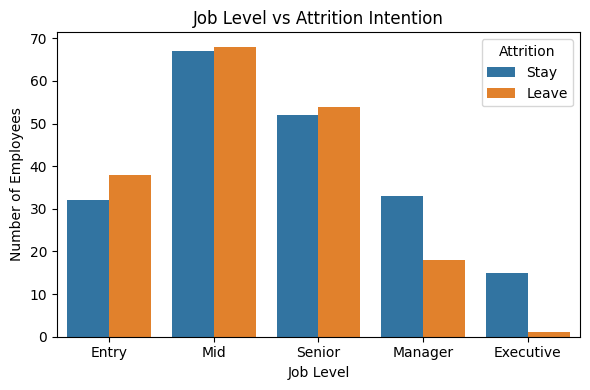

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv("Employee_Attrition_Intention Survey for thesis  Form Responses.csv")
data.columns = data.columns.str.strip()

# Target column fix
data["AttritionIntention"] = data["AttritionIntention"].astype(int)

# Job level mapping
data["JobLevelLabel"] = data["JobLevel"].map({
    1: "Entry",
    2: "Mid",
    3: "Senior",
    4: "Manager",
    5: "Executive"
})

data = data.dropna(subset=["JobLevelLabel"])

plt.figure(figsize=(6,4))

sns.countplot(
    x="JobLevelLabel",
    hue="AttritionIntention",
    data=data,
    order=["Entry","Mid","Senior","Manager","Executive"]
)

plt.title("Job Level vs Attrition Intention", fontsize=12)
plt.xlabel("Job Level")
plt.ylabel("Number of Employees")

plt.legend(title="Attrition", labels=["Stay", "Leave"])

plt.tight_layout()
plt.show()

3.8 Marital Status vs Attrition Intention

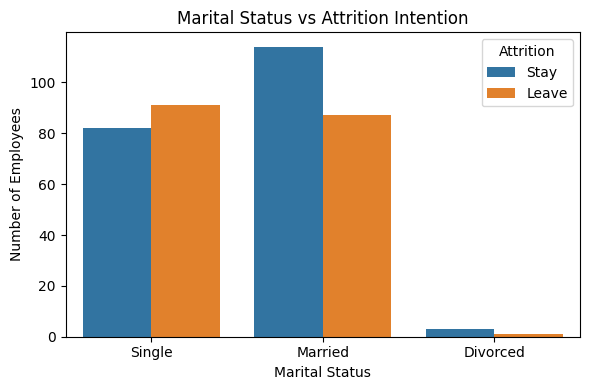

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="MaritalStatus",
    hue="AttritionIntention",
    data=data
)

plt.title("Marital Status vs Attrition Intention", fontsize=12)
plt.xlabel("Marital Status")
plt.ylabel("Number of Employees")

plt.xticks([0, 1, 2], ["Single", "Married", "Divorced"])
plt.legend(title="Attrition", labels=["Stay", "Leave"])

plt.tight_layout()
plt.show()

3.8 Correlation Heatmap

Correlation between key satisfaction variables and attrition intention.

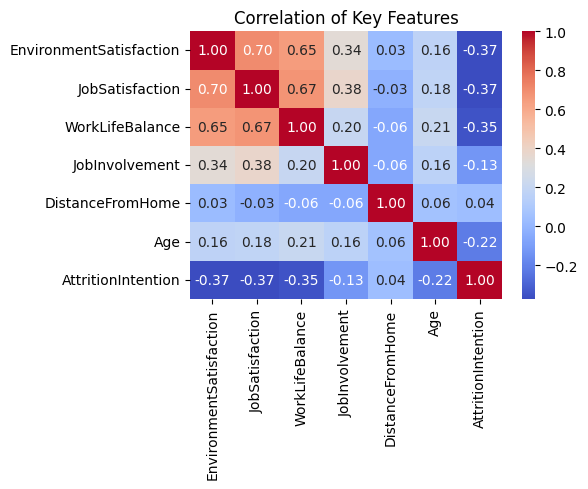

In [ ]:
important_cols = [
    "EnvironmentSatisfaction",
    "JobSatisfaction",
    "WorkLifeBalance",
    "JobInvolvement",
    "DistanceFromHome",
    "Age",
    "AttritionIntention"
]

plt.figure(figsize=(6,5))

sns.heatmap(
    data[important_cols].corr(),
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title("Correlation of Key Features")
plt.tight_layout()
plt.show()

4. Machine Learning Model Training

The dataset is split into 80% training and 20% test sets using stratified sampling. Four machine learning models are trained and compared: Logistic Regression, Decision Tree, Random Forest, and Support Vector Machine.

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# =========================================================
# 1. LOAD DATA
# =========================================================
data = pd.read_csv("Employee_Attrition_Intention Survey for thesis  Form Responses.csv")
data.columns = data.columns.str.strip()

# =========================================================
# 2. CHECK TARGET COLUMN
# =========================================================
target_col = "AttritionIntention"   # <-- use your actual target column name

if target_col not in data.columns:
    raise ValueError(f"Target column '{target_col}' not found in dataset. Available columns: {list(data.columns)}")

# =========================================================
# 3. CLEAN TARGET
# =========================================================
data[target_col] = data[target_col].astype(str).str.strip()

data[target_col] = data[target_col].map({
    "No": 0,
    "Yes": 1,
    "0": 0,
    "1": 1,
    0: 0,
    1: 1
})

# Convert everything to numeric
for col in data.columns:
    data[col] = pd.to_numeric(data[col], errors="coerce")

# Drop missing values
data = data.dropna().copy()
data[target_col] = data[target_col].astype(int)

print("After cleaning:", data.shape)
print("\nClass distribution:")
print(data[target_col].value_counts())

# =========================================================
# 4. FEATURES AND TARGET
# =========================================================
X = data.drop(columns=[target_col])
y = data[target_col]

# =========================================================
# 5. TRAIN-TEST SPLIT
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)

# =========================================================
# 6. DEFINE MODELS
# =========================================================
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_split=10,
        min_samples_leaf=4,
        class_weight="balanced",
        random_state=42
    ),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", C=1, gamma="scale", class_weight="balanced", random_state=42))
    ])
}

# =========================================================
# 7. CROSS-VALIDATION ON TRAINING SET
# =========================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\n========== CROSS-VALIDATION RESULTS ==========")
for name, model in models.items():
    acc_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
    f1_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1")

    print(f"\n{name}")
    print("CV Accuracy:", np.round(acc_scores, 4))
    print("Mean CV Accuracy:", round(acc_scores.mean(), 4))
    print("Mean CV F1:", round(f1_scores.mean(), 4))

# =========================================================
# 8. TEST SET EVALUATION
# =========================================================
print("\n========== TEST SET RESULTS ==========")
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n{name}")
    print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
    print("F1-score:", round(f1_score(y_test, y_pred), 4))
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

After cleaning: (378, 24)

Class distribution:
AttritionIntention
0    199
1    179
Name: count, dtype: int64

Train shape: (302, 23)
Test shape: (76, 23)

========== CROSS-VALIDATION RESULTS ==========

Logistic Regression
CV Accuracy: [0.6557 0.7213 0.6167 0.7    0.6333]
Mean CV Accuracy: 0.6654
Mean CV F1: 0.6352

Decision Tree
CV Accuracy: [0.7049 0.6557 0.6167 0.6667 0.55  ]
Mean CV Accuracy: 0.6388
Mean CV F1: 0.5835

Random Forest
CV Accuracy: [0.6066 0.7049 0.7667 0.7333 0.65  ]
Mean CV Accuracy: 0.6923
Mean CV F1: 0.6573

SVM
CV Accuracy: [0.6393 0.7213 0.75   0.7833 0.6167]
Mean CV Accuracy: 0.7021
Mean CV F1: 0.6766

========== TEST SET RESULTS ==========

Logistic Regression
Accuracy: 0.6842
F1-score: 0.6571
              precision    recall  f1-score   support

           0       0.69      0.72      0.71        40
           1       0.68      0.64      0.66        36

    accuracy                           0.68        76
   macro avg       0.68      0.68      0.68        7

5. Model Evaluation

Each model is evaluated using Accuracy, Precision, Recall, and F1-Score on the held-out test set.

In [ ]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "F1-score": round(f1_score(y_test, y_pred), 4)
    })

results_df = pd.DataFrame(results)
print("\nFinal Comparison:")
print(results_df.sort_values(by="F1-score", ascending=False))


Final Comparison:
                 Model  Accuracy  F1-score
2        Random Forest    0.7500    0.7164
3                  SVM    0.7237    0.6866
0  Logistic Regression    0.6842    0.6571
1        Decision Tree    0.6316    0.5625


5.1 Model Accuracy Comparison

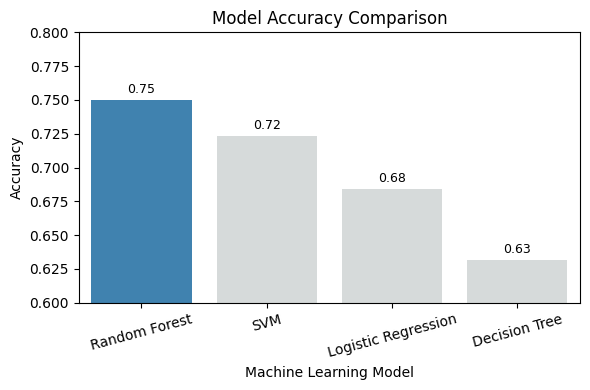

In [ ]:
results_df = results_df.sort_values(by="Accuracy", ascending=False)

plt.figure(figsize=(6,4))

ax = sns.barplot(
    x="Model",
    y="Accuracy",
    hue="Model",          #  add this
    data=results_df,
    palette=['#2E86C1'] + ['#D5DBDB']*(len(results_df)-1),
    legend=False          #  remove duplicate legend
)

# Add values on bars
for i, v in enumerate(results_df["Accuracy"]):
    ax.text(i, v + 0.005, f"{v:.2f}", ha='center', fontsize=9)

plt.title("Model Accuracy Comparison", fontsize=12)
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")

plt.ylim(0.6, 0.8)
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

5.2 ROC Curve and AUC Analysis

ROC curves and AUC values for all four models to assess overall classification performance.

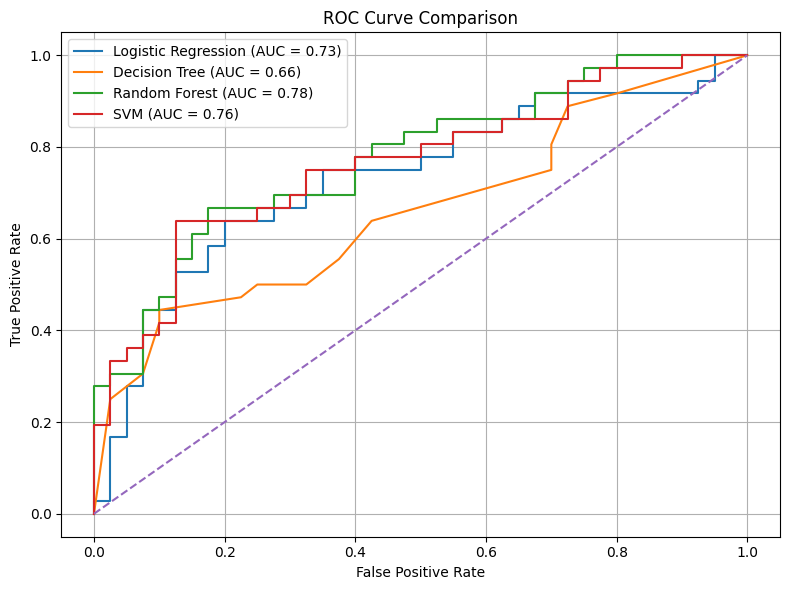

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Fit models again
for name, model in models.items():
    model.fit(X_train, y_train)

plt.figure(figsize=(8,6))

for name, model in models.items():
    if name == "SVM":
        y_score = model.decision_function(X_test)
    else:
        y_score = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**6. SHAP Analysis**

SHAP (SHapley Additive Explanations) is applied to the Random Forest model to explain which features most strongly influence employee attrition intention.

6.1 SHAP Beeswarm Summary Plot

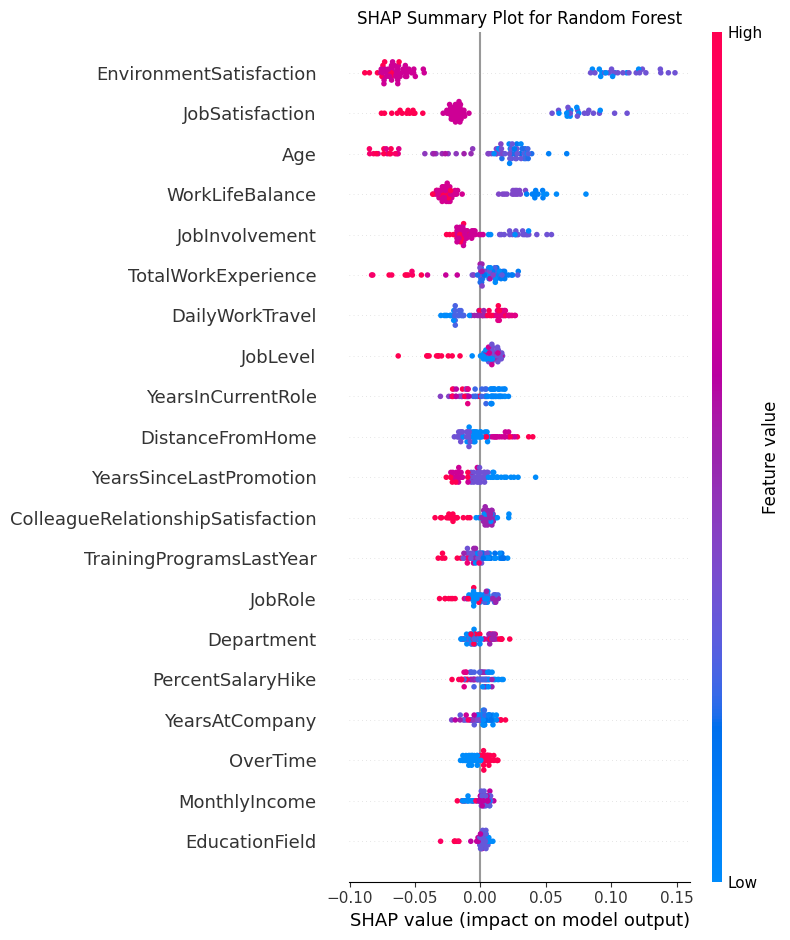

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
import shap
import matplotlib.pyplot as plt

# Use same split as thesis
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train Random Forest with THESIS settings
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train, y_train)

# SHAP Explainer
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

# Plot
if isinstance(shap_values, list):
    shap.summary_plot(shap_values[1], X_test, show=False)
else:
    shap.summary_plot(shap_values[:, :, 1], X_test, show=False)

plt.title("SHAP Summary Plot for Random Forest")
plt.tight_layout()
plt.show()

In [ ]:
# Train Random Forest model
rf_model = models["Random Forest"]

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=8, min_samples_leaf=4,
                       min_samples_split=10, n_estimators=200, random_state=42)

In [ ]:
import shap

# Create SHAP explainer
explainer = shap.TreeExplainer(rf_model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test)

In [ ]:
# For Leave class (1)
shap_class1 = shap_values[1]

6.2 SHAP Feature Importance Bar Chart

Mean absolute SHAP values showing the overall importance of each feature.

SHAP shape: (76, 23, 2)
X_test shape: (76, 23)


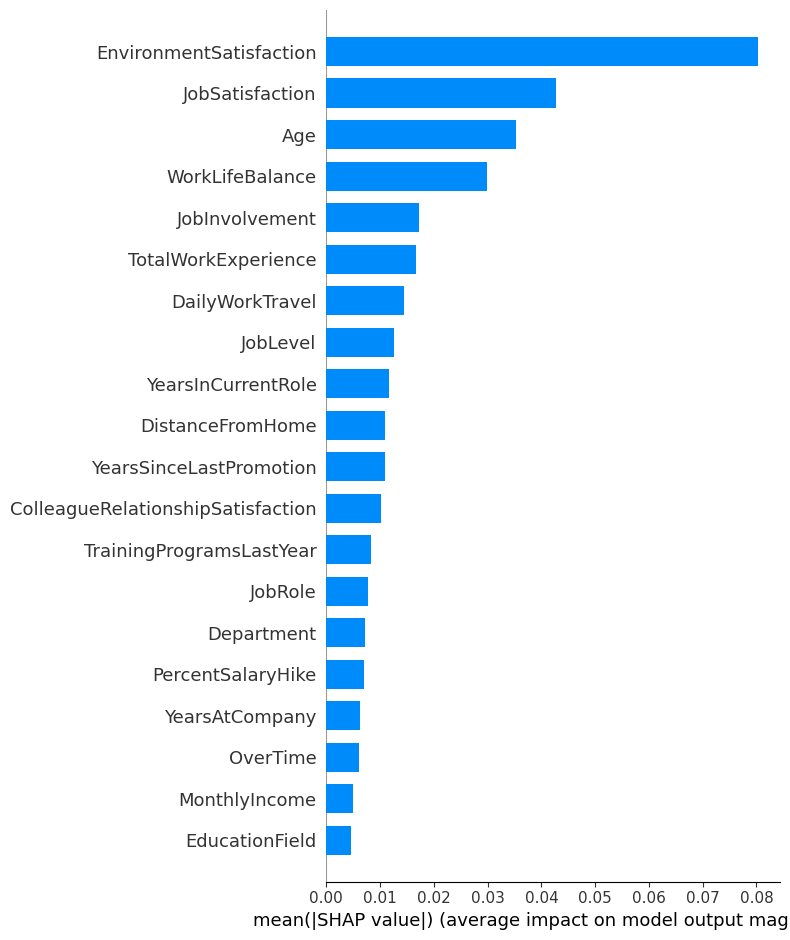

In [ ]:
import shap
import matplotlib.pyplot as plt

# Train Random Forest
rf_model = models["Random Forest"]
rf_model.fit(X_train, y_train)

# SHAP explainer
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

# Check shape
print("SHAP shape:", np.array(shap_values).shape)
print("X_test shape:", X_test.shape)

# Select SHAP values for Leave class (class 1)
if isinstance(shap_values, list):
    shap_class1 = shap_values[1]
else:
    shap_class1 = shap_values[:, :, 1]

# Bar plot
shap.summary_plot(shap_class1, X_test, plot_type="bar")